In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [22]:

sns.set(font_scale=1.2)

try:
    
    np.random.seed(42)  

    n_samples = 100


    datos = {
        'id': range(1, n_samples + 1),
        'toxicity_level': np.random.uniform(0.1, 9.9, n_samples).round(2),
        'environmental_persistence_days': np.random.randint(10, 1000, n_samples),
        'infectious_risk': np.random.uniform(0, 5, n_samples).round(1),
        'treatment_cost': np.random.uniform(50, 500, n_samples).round(2),
        'waste_volume_liters': np.random.uniform(0.5, 100, n_samples).round(1),
        'water_impact': np.random.uniform(1, 10, n_samples).round(1),
        'ground_impact': np.random.uniform(1, 10, n_samples).round(1),
        'air_impact': np.random.uniform(1, 10, n_samples).round(1),
        'origin': np.random.choice(['Hospital', 'Laboratorio', 'Farmacéutica', 'Clínica'], n_samples)
    }

    
    df = pd.DataFrame(datos)

    
    df['total_environmental_impact'] = (
        0.5 * df['toxicity_level'] +
        0.003 * df['environmental_persistence_days'] +
        0.2 * df['infectious_risk'] +
        0.4 * df['water_impact'] +
        0.3 * df['ground_impact'] +
        0.3 * df['air_impact'] +
        np.random.normal(0, 0.5, n_samples)
    ).round(2)


    print("Base de datos de sustancias químicas y residuos médicos:")
    print(df.head())


    print("\nEstadísticas descriptivas:")
    print(df.describe())

    
    print("\nValores nulos en el dataset original:")
    print(df.isnull().sum())

    indices_nulos = np.random.choice(df.index, size=10)
    
    
    df_mod = df.copy()
    df_mod.loc[indices_nulos, 'toxicity_level'] = np.nan
    
 
    df_mod['toxicity_level'] = df_mod['toxicity_level'].fillna(df_mod['toxicity_level'].mean())
    
    df = df_mod


    import os
    if not os.path.exists('images'):
        os.makedirs('images')


    plt.figure(figsize=(10, 6))
    sns.histplot(df['toxicity_level'], kde=True)
    plt.title('Distribución de Niveles de Toxicidad')
    plt.xlabel('Nivel de Toxicidad')
    plt.ylabel('Frecuencia')
    plt.savefig('images/distribucion_toxicidad.png')
    plt.close()

    plt.figure(figsize=(12, 8))
    sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Matriz de Correlación de Variables')
    plt.tight_layout()
    plt.savefig('images/correlacion_variables.png')
    plt.close()

   
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='origin', y='toxicity_level', data=df)
    plt.title('Nivel de Toxicidad por origin')
    plt.xlabel('origin')
    plt.ylabel('Nivel de Toxicidad')
    plt.tight_layout()
    plt.savefig('images/toxicidad_por_origin.png')
    plt.close()


    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='water_impact', y='total_environmental_impact', hue='origin', data=df)
    plt.title('Relación entre Impacto al Agua e Impacto Ambiental Total')
    plt.xlabel('Impacto al Agua')
    plt.ylabel('Impacto Ambiental Total')
    plt.tight_layout()
    plt.savefig('images/water_impact_vs_total.png')
    plt.close()


    X = df[['toxicity_level', 'environmental_persistence_days', 'infectious_risk', 
           'water_impact', 'ground_impact', 'air_impact']]
    y = df['total_environmental_impact']

  
 
    X_train, X_test, y_train, y_test = train_test_split(X, y)
    modelo = LinearRegression()
    modelo.fit(X_train, y_train)


    y_pred = modelo.predict(X_test)


    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print("\nResultados del modelo de regresión lineal:")
    print(f"Mean square error (MSE): {mse:.4f}")
    print(f"Coefficient of determination (R²): {r2:.4f}")

 
    print("\nCoeficientes del modelo:")
    for i, columna in enumerate(X.columns):
        print(f"{columna}: {modelo.coef_[i]:.4f}")
    print(f"Intercepto: {modelo.intercept_:.4f}")


    

 
    df.to_csv('analysis_results.csv', index=False)

 
    print("\nConclusions and Recommendations:")
    print("1. Substances with a higher level of toxicity and environmental persistence require")
    print(" special treatment according to WHO guidelines.")
    print("2. The impact on water shows the strongest correlation with the total environmental impact,")
    print(" which supports the IPCC's approach to protecting water resources.")
    print("3. Waste of hospital origin presents greater variability in toxicity levels,")
    print(" suggesting the need for more specific protocols according to CDC.")
    print("4. The regression model identifies the most influential factors in environmental impact,")
    print(" allowing interventions to be prioritized according to current scientific recommendations.")

except Exception as e:
    print(f"Error en la ejecución del código: {e}")
    import traceback
    traceback.print_exc()

Base de datos de sustancias químicas y residuos médicos:
   id  toxicity_level  environmental_persistence_days  infectious_risk  \
0   1            3.77                             584              0.7   
1   2            9.42                             873              2.4   
2   3            7.27                             752              4.9   
3   4            5.97                             250              1.2   
4   5            1.63                             573              3.4   

   treatment_cost  waste_volume_liters  water_impact  ground_impact  \
0          433.01                 66.0           4.8            6.0   
1          192.61                 16.7           9.2            6.0   
2          126.27                  7.5           2.0            8.9   
3          300.56                 64.4           5.4            4.6   
4          471.27                  3.1           1.1            2.2   

   air_impact        origin  total_environmental_impact  
0         6.3

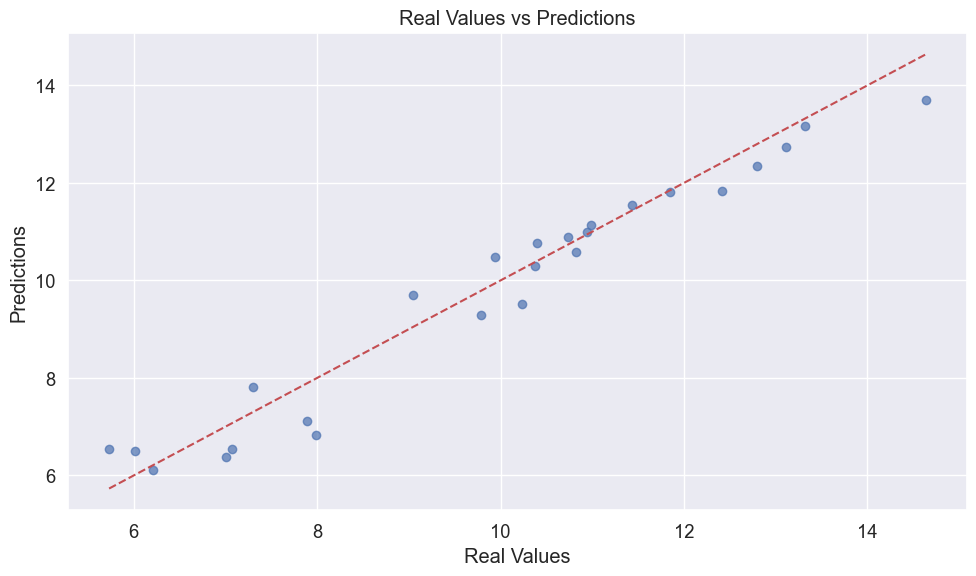

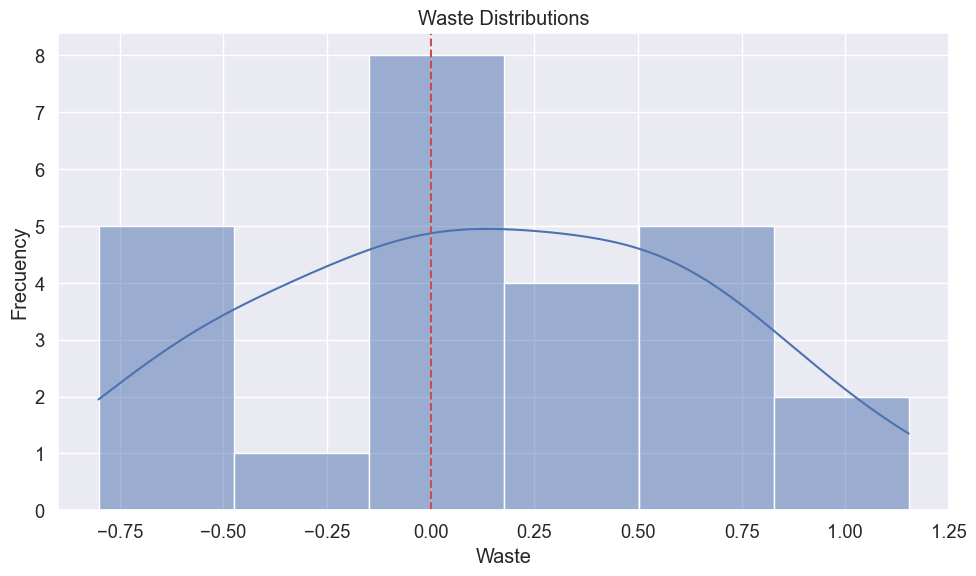

In [10]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Real Values vs Predictions')
plt.xlabel('Real Values')
plt.ylabel('Predictions')
plt.tight_layout()
plt.show()  

# Plot: Residual Distribution
residuos = y_test - y_pred
plt.figure(figsize=(10, 6))
sns.histplot(residuos, kde=True)
plt.title('Waste Distributions')
plt.xlabel('Waste')
plt.ylabel('Frecuency')
plt.axvline(x=0, color='r', linestyle='--')
plt.tight_layout()
plt.show()  

In [23]:
df_t = pd.read_csv('./analysis_results.csv', header='infer')

In [24]:
df_t.head()

,id,toxicity_level,environmental_persistence_days,infectious_risk,treatment_cost,waste_volume_liters,water_impact,ground_impact,air_impact,origin,total_environmental_impact
0,1,3.770000,584,0.7,433.01,66.0,4.8,6.0,6.3,Farmacéutica,10.33
1,2,9.420000,873,2.4,192.61,16.7,9.2,6.0,7.7,Farmacéutica,16.27
2,3,7.270000,752,4.9,126.27,7.5,2.0,8.9,4.9,Clínica,12.61
3,4,4.758889,250,1.2,300.56,64.4,5.4,4.6,2.1,Laboratorio,7.89
4,5,1.630000,573,3.4,471.27,3.1,1.1,2.2,3.6,Clínica,4.90
